# PCA-Based Event Detection Using Moving Windows

This notebook implements a reconstruction-based event detection workflow using principal component analysis (PCA). The example uses the synthetic three-tank system (TTS) dataset generated in the accompanying data-generation tutorial.

The workflow follows the moving-window formulation used in the manuscript:

$$
\mathbf{X}_k \in \mathbb{R}^{M_k \times n}, \qquad k = 1,\dots,K
$$

where each $\mathbf{X}_k$ is a local time-series window (matrix) containing $M_k$ samples and $n$ measured process variables. PCA is trained using windows from nominal operation, and event signatures are identified through the window-wise reconstruction error $\varepsilon_k$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA

## Load the Synthetic Three-Tank System Dataset

The dataset contains the measured liquid-level signals $h_1(t)$, $h_2(t)$, and $h_3(t)$, together with true states, inputs, flows, and fault labels. For PCA-based event detection, we use only the measured liquid-level variables as the multivariate monitoring data:

$$
\mathbf{x}(t) =
\begin{bmatrix}
h_1(t) & h_2(t) & h_3(t)
\end{bmatrix}^{T}
$$

The code below loads `TTS_multifault_short_events.csv`. Update `csv_path` if the dataset is stored in a different directory.

In [2]:
# Load data

csv_path = Path("../Example_Dataset/TTS_multifault_short_events.csv")

# If the CSV is in the same folder as this notebook, use:
# csv_path = Path("TTS_multifault_short_events.csv")

df = pd.read_csv(csv_path)

print(f"Loaded: {csv_path}")
print(df.head())

Loaded: TTS_multifault_short_events.csv
     t    q1_cmd    q3_cmd   h1_true   h2_true   h3_true   h1_meas   h2_meas  \
0  0.0  0.000022  0.000014  0.120000  0.100000  0.080000  0.119505  0.100718   
1  1.0  0.000022  0.000014  0.118991  0.099900  0.077705  0.118807  0.100908   
2  2.0  0.000022  0.000014  0.118033  0.099630  0.075610  0.118677  0.098973   
3  3.0  0.000022  0.000014  0.117114  0.099226  0.073687  0.117211  0.099146   
4  4.0  0.000022  0.000014  0.116224  0.098715  0.071911  0.116684  0.098793   

    h3_meas  q12_true  q23_true   q2_true  fault_active fault_type  fault_id  
0  0.080067  0.000038  0.000038  0.000088             0     normal        -1  
1  0.077018  0.000037  0.000040  0.000086             0     normal        -1  
2  0.075740  0.000036  0.000041  0.000085             0     normal        -1  
3  0.072973  0.000036  0.000042  0.000084             0     normal        -1  
4  0.072570  0.000035  0.000044  0.000083             0     normal        -1  


## Select Measured Variables and Normalize

We use the noisy measured variables as the monitoring signals:

$$
\mathbf{X} =
\begin{bmatrix}
\mathbf{x}(t_1)^T \\
\mathbf{x}(t_2)^T \\
\vdots \\
\mathbf{x}(t_M)^T
\end{bmatrix}
\in \mathbb{R}^{M \times n}
$$

where $M$ is the number of time samples and $n=3$ for this synthetic TTS example.

Each variable is normalized to $[0,1]$ so that the reconstruction error is not dominated by differences in variable scale.

In [3]:
# Variable Normalization

time_col = "t"
meas_cols = ["h1_meas", "h2_meas", "h3_meas"]

t = df[time_col].to_numpy(dtype=float)
X_raw = df[meas_cols].copy()

# Linear interpolation fills short NaN gaps; bfill/ffill handle edge cases
X_raw = X_raw.interpolate(method="linear", limit_direction="both")
X_raw = X_raw.bfill().ffill()

X = X_raw.to_numpy(dtype=float)

# Min-max normalization for each measured variable.
x_min = X.min(axis=0, keepdims=True)
x_max = X.max(axis=0, keepdims=True)
data_norm = (X - x_min) / (x_max - x_min + 1e-12)

print("Normalized data shape:", data_norm.shape)

Normalized data shape: (4001, 3)


## Construct Moving Windows

TThe PCA reconstruction error is computed on a moving-window basis. Each window is represented as:

$$
W_k = [\tau_k^s, \tau_k^e], \qquad k=1,\dots,K
$$

and the data contained in the window are:

$$
\mathbf{X}_k \in \mathbb{R}^{M_k \times n}
$$

For this synthetic example, we use:

- window size = 60 samples,
- overlap = 10%.

The representative time of each window is taken as the start time:

$$
\tau_k = \tau_k^s
$$

This maps the window-wise monitoring metric back to the original time axis.

In [4]:
# Moving-window 

window_size = 60
overlap = 0.10
stride = int(round(window_size * (1.0 - overlap)))

if stride < 1:
    raise ValueError("Stride must be at least 1. Reduce overlap or increase window_size.")

start_indices = np.arange(0, len(data_norm) - window_size + 1, stride, dtype=int)
end_indices = start_indices + window_size

X_windows = [data_norm[s:e, :] for s, e in zip(start_indices, end_indices)]

# Representative time for each window: start time of window
tau = t[start_indices]

print("Number of windows:", len(X_windows))

Number of windows: 73


## Train PCA Using Nominal Windows

The PCA model is trained only using nominal operation data. Here, we assume that the first six windows correspond to normal operation:

$$
\{\mathbf{X}_1, \mathbf{X}_2, \dots, \mathbf{X}_6\}
$$

The normal windows are concatenated sample-wise to estimate the PCA loading matrix $\mathbf{P}$. The number of retained principal components is selected such that 90% of the training variance is captured.

In [5]:
# Train PCA 

n_train_windows = 6

if len(X_windows) <= n_train_windows:
    raise ValueError("Not enough windows. Increase the time horizon or reduce the window size.")

X_train = np.vstack(X_windows[:n_train_windows])

pca = PCA(n_components=0.90)
pca.fit(X_train)

PCA(n_components=0.9)

## Compute Window-Wise PCA Reconstruction Error

For each moving window, PCA projects the data into a lower-dimensional subspace:

$$
\mathbf{T}_k = \mathbf{X}_k \mathbf{P}
$$

and reconstructs the window as:

$$
\widehat{\mathbf{X}}_k = \mathbf{T}_k \mathbf{P}^{T}
$$

The event-detection metric is the reconstruction error:

$$
\varepsilon_k = \|\mathbf{X}_k - \widehat{\mathbf{X}}_k\|
$$

Large values of $\varepsilon_k$ indicate that the current window departs from the nominal PCA subspace.

In [6]:
# PCA reconstruction error

epsilon = np.zeros(len(X_windows), dtype=float)

for k, Xk in enumerate(X_windows):
    Tk = pca.transform(Xk)
    Xk_hat = pca.inverse_transform(Tk)
    epsilon[k] = np.linalg.norm(Xk - Xk_hat, ord="fro")

epsilon_train = epsilon[:n_train_windows]

## Smooth the Reconstruction-Error Profile

A light exponential moving average (EMA) is used to reduce high-frequency fluctuations in the window-wise reconstruction-error profile:

$$
\bar{\varepsilon}_k
=
\alpha \varepsilon_k
+
(1-\alpha)\bar{\varepsilon}_{k-1}
$$

This step is *optional*, but it often makes the visualization easier to interpret.

In [7]:
# Optional smoothing

def ema(x, alpha=0.60):
    y = np.empty_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1.0 - alpha) * y[i - 1]
    return y

epsilon_plot = ema(epsilon, alpha=0.60)

## Plot PCA-Based Event Detection Results

The reconstruction-error sequence $\varepsilon_k$ is plotted against the representative time $\tau_k$, which maps the window-scale result back to the original physical time axis of the process.

For this synthetic TTS dataset, the monitoring horizon is approximately 4000 minutes.

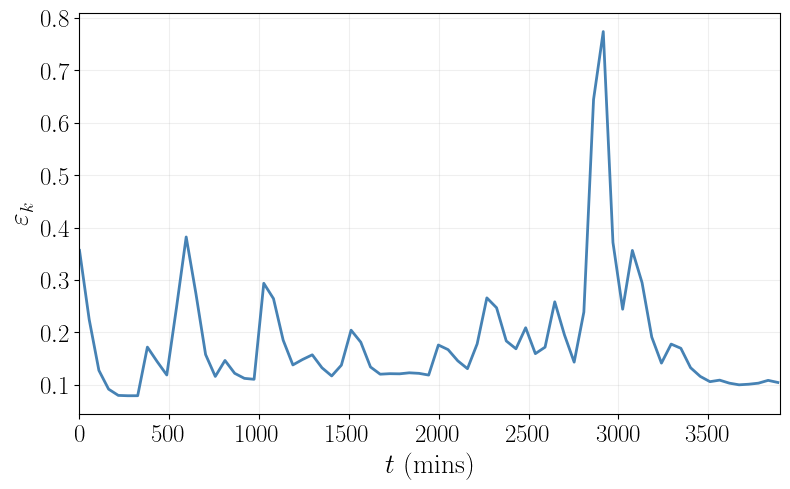

In [8]:
# Plot PCA reconstruction error

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.titlesize": 22,
    "legend.fontsize": 14,
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    tau,
    epsilon_plot,
    color="steelblue",
    lw=2.0
)

ax.set_xlabel(r"$t$ (mins)")
ax.set_ylabel(r"$\varepsilon_k$")
ax.set_xlim(0, 3900)
ax.grid(True, alpha=0.20)

plt.tight_layout()
plt.show()